In [5]:
import joblib
print(joblib.__version__)

1.5.3


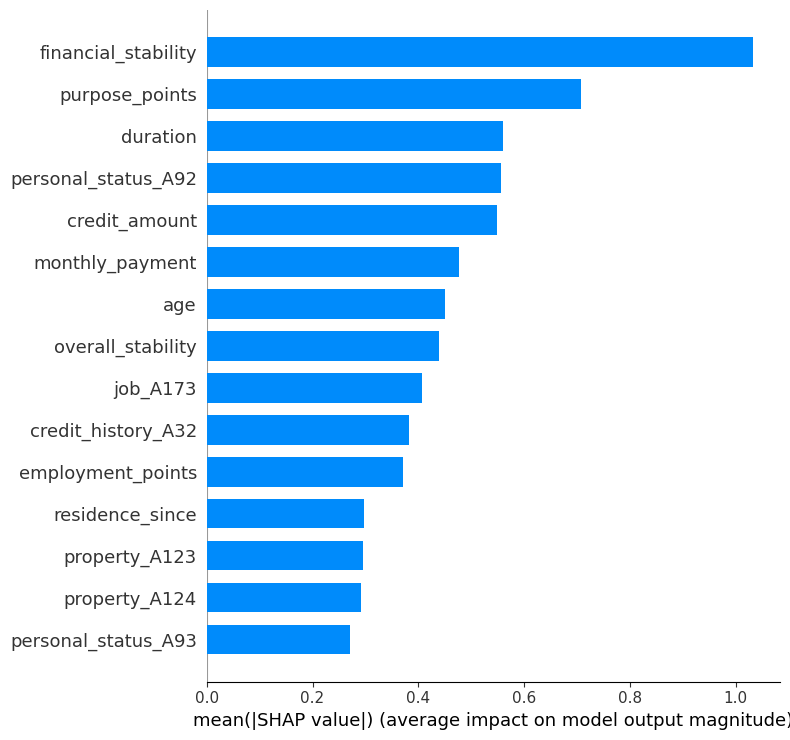

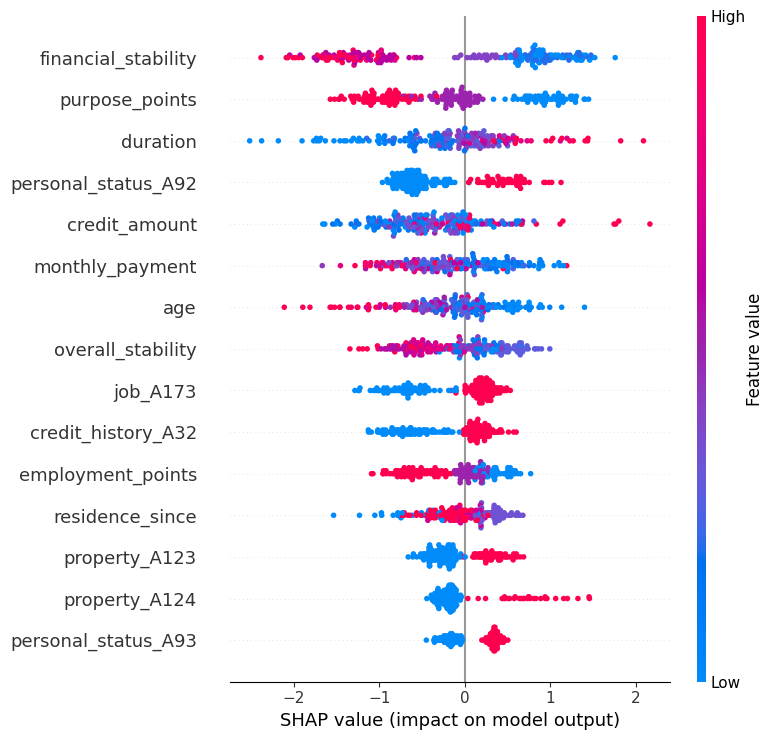

False negatives at t=0.35: 15


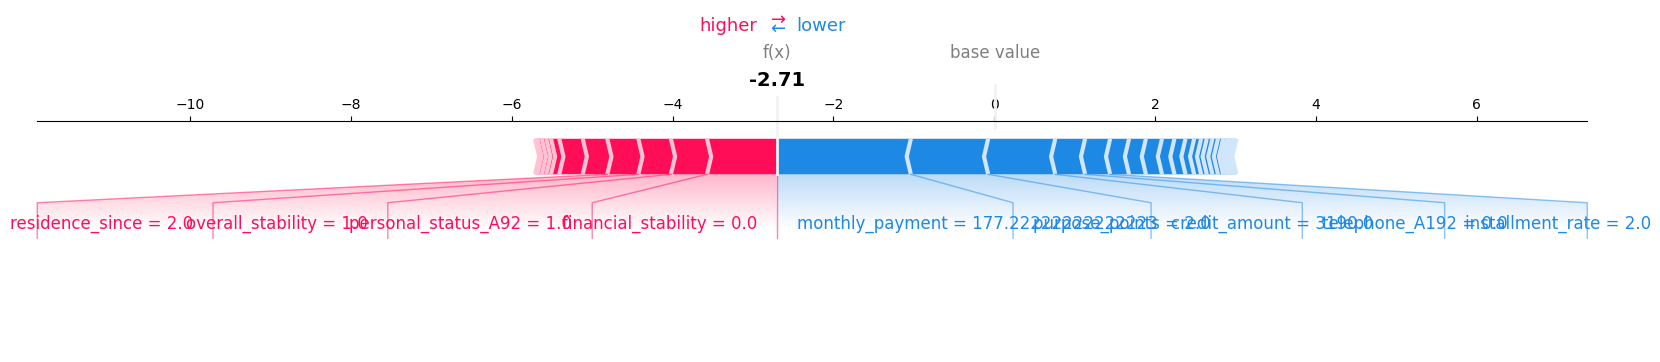

In [6]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import joblib

model = joblib.load("../models/xgb_final.pkl")
X_train, X_test, y_train, y_test = joblib.load("../data/processed/train_test_split.pkl")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15)

shap.summary_plot(shap_values, X_test, max_display=15)

# 3. One false negative example — a defaulter your model missed
import numpy as np
y_pred_proba = model.predict_proba(X_test)[:, 1]
fn_indices = np.where((y_test.values == 1) & (y_pred_proba < 0.35))[0]

print(f"False negatives at t=0.35: {len(fn_indices)}")
shap.force_plot(
    explainer.expected_value,
    shap_values[fn_indices[0]],
    X_test.iloc[fn_indices[0]],
    matplotlib=True
)



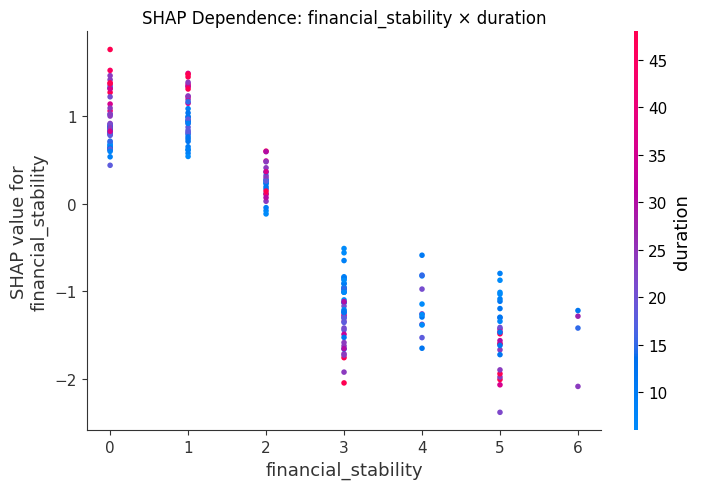

In [8]:
shap.dependence_plot(
  "financial_stability",
  shap_values,
		X_test,
  interaction_index="duration",
  show=False
)

plt.title("SHAP Dependence: financial_stability × duration")
plt.tight_layout()
plt.savefig('../models/shap_dependence.png')
plt.show()